# 3D Hagen-Poiseuille Flow in a Cylindrical Pipe

Simulates pressure-driven flow through a cylindrical pipe using the D3Q19 Lattice Boltzmann Method (LBM) with JAX.

**Boundary conditions:**
- Zou-He pressure BC at inlet (x=0) and outlet (x=NX-1)
- Bounce-back no-slip on the cylindrical pipe wall

**Analytical solution (cylindrical pipe):**
$$u(r) = \frac{-\partial_x p}{4\nu}(R^2 - r^2)$$

In [15]:
%matplotlib inline

import jax
import jax.numpy as jnp
from jax import jit
import numpy as np
import time
import matplotlib.pyplot as plt

print(f"JAX devices: {jax.devices()}")

JAX devices: [cuda(id=0), cuda(id=1), cuda(id=2)]


## Parameters

In [16]:
NX, NY, NZ = 200, 80, 80  # Channel dimensions (length x height x width)
TAU = 0.8                 # Relaxation time
OMEGA = 1.0 / TAU         # Relaxation parameter
NU = (TAU - 0.5) / 3.0    # Kinematic viscosity (derived from TAU)
DELTA_P = 0.001            # Total pressure drop (rho_in - rho_out)
RHO_IN = 1.0 + DELTA_P / 2.0
RHO_OUT = 1.0 - DELTA_P / 2.0
MAX_STEPS = 30000
PRINT_EVERY = 5000
Q = 19

print(f"Grid: {NX}x{NY}x{NZ}  tau={TAU}  omega={OMEGA:.4f}  nu={NU:.6f}")
print(f"rho_in={RHO_IN:.6f}  rho_out={RHO_OUT:.6f}  dP={DELTA_P}")

Grid: 200x80x80  tau=0.8  omega=1.2500  nu=0.100000
rho_in=1.000500  rho_out=0.999500  dP=0.001


## D3Q19 Lattice Constants

In [17]:
C = np.array([
    [0, 0, 0],                                          # 0  rest
    [1, 0, 0], [-1, 0, 0], [0, 1, 0], [0, -1, 0],      # 1-4  face
    [0, 0, 1], [0, 0, -1],                              # 5-6  face
    [1, 1, 0], [-1, -1, 0], [1, -1, 0], [-1, 1, 0],    # 7-10 edge
    [1, 0, 1], [-1, 0, -1], [1, 0, -1], [-1, 0, 1],    # 11-14 edge
    [0, 1, 1], [0, -1, -1], [0, 1, -1], [0, -1, 1],    # 15-18 edge
], dtype=np.int32)

W = np.array([1./3.] + [1./18.]*6 + [1./36.]*12)
OPP = np.array([0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15, 18, 17])

# JAX arrays reshaped for broadcasting: (Q,1,1,1) for 3D fields, (Q,1,1) for 2D slices
cx4 = jnp.array(C[:, 0]).reshape(Q, 1, 1, 1)
cy4 = jnp.array(C[:, 1]).reshape(Q, 1, 1, 1)
cz4 = jnp.array(C[:, 2]).reshape(Q, 1, 1, 1)
w4  = jnp.array(W).reshape(Q, 1, 1, 1)

cx2 = jnp.array(C[:, 0]).reshape(Q, 1, 1)
cy2 = jnp.array(C[:, 1]).reshape(Q, 1, 1)
cz2 = jnp.array(C[:, 2]).reshape(Q, 1, 1)
w2  = jnp.array(W).reshape(Q, 1, 1)

opp = jnp.array(OPP)

# Indices for Zou-He: populations moving in +x, -x, and zero-x directions
POS_X = jnp.array([1, 7, 9, 11, 13])   # cx > 0
NEG_X = jnp.array([2, 8, 10, 12, 14])  # cx < 0
ZERO_X = jnp.array([0, 3, 4, 5, 6, 15, 16, 17, 18])  # cx == 0

## Geometry: Cylindrical Pipe

In [18]:
R_pipe = (NY - 2) / 2.0  # Pipe radius (leave 1-cell margin for wall nodes)
CY_pipe = NY / 2.0       # Center of pipe in Y
CZ_pipe = NZ / 2.0       # Center of pipe in Z

Y, Z = np.meshgrid(np.arange(NY), np.arange(NZ), indexing='ij')
dist_from_axis = np.sqrt((Y + 0.5 - CY_pipe)**2 + (Z + 0.5 - CZ_pipe)**2)

# Build 3D geometry: 0 = fluid, 1 = solid (bounce-back)
geo = np.zeros((NX, NY, NZ), dtype=np.int32)
wall_2d = dist_from_axis >= R_pipe  # Cylindrical wall
for ix in range(NX):
    geo[ix, wall_2d] = 1

is_solid = jnp.array(geo == 1)[None]  # (1, NX, NY, NZ)

n_fluid = int(np.sum(geo[NX // 2] == 0))
print(f"Pipe radius: {R_pipe:.1f} lu, fluid nodes per cross-section: {n_fluid}")

# Inlet/outlet masks: fluid nodes at x=0 and x=NX-1 (2D: NY x NZ)
inlet_fluid_2d = jnp.array(~wall_2d)[None]   # (1, NY, NZ)
outlet_fluid_2d = jnp.array(~wall_2d)[None]

Pipe radius: 39.0 lu, fluid nodes per cross-section: 4792


## LBM Core Functions

In [19]:
def equilibrium_3d(rho, ux, uy, uz):
    """Compute equilibrium distribution for 3D field."""
    usq = ux * ux + uy * uy + uz * uz
    cu = cx4 * ux[None] + cy4 * uy[None] + cz4 * uz[None]
    return w4 * rho[None] * (1.0 + 3.0 * cu + 4.5 * cu * cu - 1.5 * usq[None])


def equilibrium_2d(rho, ux, uy, uz):
    """Compute equilibrium distribution for a 2D slice (NY x NZ)."""
    usq = ux * ux + uy * uy + uz * uz
    cu = cx2 * ux[None] + cy2 * uy[None] + cz2 * uz[None]
    return w2 * rho[None] * (1.0 + 3.0 * cu + 4.5 * cu * cu - 1.5 * usq[None])


def macroscopic(f):
    """Compute macroscopic density and velocity from distributions."""
    rho = jnp.sum(f, axis=0)
    ux = jnp.sum(f * cx4, axis=0) / rho
    uy = jnp.sum(f * cy4, axis=0) / rho
    uz = jnp.sum(f * cz4, axis=0) / rho
    return rho, ux, uy, uz


def stream(f):
    """Stream distributions along lattice velocities using periodic shifts."""
    out = jnp.zeros_like(f)
    for q in range(Q):
        s = jnp.roll(f[q], C[q, 0], axis=0)
        s = jnp.roll(s, C[q, 1], axis=1)
        s = jnp.roll(s, C[q, 2], axis=2)
        out = out.at[q].set(s)
    return out

## Zou-He Boundary Conditions

In [20]:
def zou_he_inlet(f):
    """
    Zou-He pressure inlet at x=0.
    Known: rho_in. Unknown: f[POS_X] (populations entering the domain).
    """
    s = f[:, 0, :, :]  # (Q, NY, NZ)
    rho_in = RHO_IN * jnp.ones((NY, NZ))

    # Compute ux from the known populations and prescribed density
    sum_zero = jnp.sum(s[ZERO_X], axis=0)
    sum_neg = jnp.sum(s[NEG_X], axis=0)
    ux_in = 1.0 - (sum_zero + 2.0 * sum_neg) / rho_in

    # Non-equilibrium bounce-back for unknown populations
    # f_i = f_opp(i) + (f_eq_i - f_eq_opp(i))
    feq_in = equilibrium_2d(rho_in, ux_in, jnp.zeros((NY, NZ)), jnp.zeros((NY, NZ)))

    # Update only the 5 unknown populations (POS_X) at fluid inlet nodes
    for idx in range(5):
        i_pos = POS_X[idx]
        i_neg = NEG_X[idx]
        new_val = s[i_neg] + (feq_in[i_pos] - feq_in[i_neg])
        new_val = jnp.where(inlet_fluid_2d[0], new_val, s[i_pos])
        f = f.at[i_pos, 0, :, :].set(new_val)
    return f


def zou_he_outlet(f):
    """
    Zou-He pressure outlet at x=NX-1.
    Known: rho_out. Unknown: f[NEG_X] (populations leaving into the domain).
    """
    s = f[:, -1, :, :]  # (Q, NY, NZ)
    rho_out = RHO_OUT * jnp.ones((NY, NZ))

    # Compute ux from the known populations and prescribed density
    sum_zero = jnp.sum(s[ZERO_X], axis=0)
    sum_pos = jnp.sum(s[POS_X], axis=0)
    ux_out = -1.0 + (sum_zero + 2.0 * sum_pos) / rho_out

    # Non-equilibrium bounce-back for unknown populations
    feq_out = equilibrium_2d(rho_out, ux_out, jnp.zeros((NY, NZ)), jnp.zeros((NY, NZ)))

    # Update only the 5 unknown populations (NEG_X) at fluid outlet nodes
    for idx in range(5):
        i_neg = NEG_X[idx]
        i_pos = POS_X[idx]
        new_val = s[i_pos] + (feq_out[i_neg] - feq_out[i_pos])
        new_val = jnp.where(outlet_fluid_2d[0], new_val, s[i_neg])
        f = f.at[i_neg, -1, :, :].set(new_val)
    return f

## LBM Time Step

In [21]:
@jit
def one_step(f, is_solid):
    """Perform one LBM time step: collide -> bounce-back -> stream -> BCs."""
    # Macroscopic quantities
    rho, ux, uy, uz = macroscopic(f)

    # Equilibrium
    feq = equilibrium_3d(rho, ux, uy, uz)

    # BGK collision for fluid, bounce-back for solid
    f_coll = f - OMEGA * (f - feq)
    f_bb = f[opp]  # Bounce-back: reverse populations
    f_coll = jnp.where(is_solid, f_bb, f_coll)

    # Streaming
    f_str = stream(f_coll)

    # Zou-He pressure boundary conditions
    f_str = zou_he_inlet(f_str)
    f_str = zou_he_outlet(f_str)

    return f_str

## Initialization & Simulation

In [22]:
# Initialize with linear pressure gradient
print("Initialising with linear pressure gradient...")
x = np.arange(NX, dtype=np.float64)
rho0_1d = RHO_IN - (RHO_IN - RHO_OUT) * x / (NX - 1)
rho0 = jnp.array(np.broadcast_to(rho0_1d[:, None, None], (NX, NY, NZ)).copy())
z_field = jnp.zeros((NX, NY, NZ))
f = equilibrium_3d(rho0, z_field, z_field, z_field)

# JIT compile
print("JIT compiling...")
t0 = time.time()
f = one_step(f, is_solid)
f.block_until_ready()
print(f"JIT compile time: {time.time() - t0:.1f}s")

# Main simulation loop
print(f"\nRunning {MAX_STEPS} steps...")
t0 = time.time()

for step in range(1, MAX_STEPS + 1):
    f = one_step(f, is_solid)
    if step % PRINT_EVERY == 0:
        f.block_until_ready()
        rho, ux, uy, uz = macroscopic(f)
        mean_ux = float(jnp.mean(ux[NX // 2, ~wall_2d]))
        print(f"  step {step:6d}  <u_x> at mid-plane = {mean_ux:.6e}")

elapsed = time.time() - t0
print(f"Simulation done in {elapsed:.1f}s ({MAX_STEPS / elapsed:.0f} steps/s)")

Initialising with linear pressure gradient...
JIT compiling...
JIT compile time: 0.7s

Running 30000 steps...
  step   5000  <u_x> at mid-plane = 2.716200e-03
  step  10000  <u_x> at mid-plane = 3.100017e-03
  step  15000  <u_x> at mid-plane = 3.157137e-03
  step  20000  <u_x> at mid-plane = 3.165758e-03
  step  25000  <u_x> at mid-plane = 3.167257e-03
  step  30000  <u_x> at mid-plane = 3.167520e-03
Simulation done in 72.8s (412 steps/s)


## Post-Processing & Analytical Comparison

In [23]:
rho, ux, uy, uz = macroscopic(f)
ux_np = np.array(ux)
rho_np = np.array(rho)

z_mid = NZ // 2
r_coords = np.arange(NY) + 0.5 - CY_pipe  # Distance from center
fluid_mask_radial = ~wall_2d[:, z_mid]
r_fluid = r_coords[fluid_mask_radial]

# Analytical Hagen-Poiseuille solution
# u(r) = -dp_dx / (4 * nu) * (R^2 - r^2)  [factor 4 for cylindrical pipe, not 2 as in planar]
dp_dx = (RHO_OUT - RHO_IN) / (3.0 * (NX - 1))  # Negative (pressure drops)
r_analytical = np.linspace(-R_pipe, R_pipe, 200)
u_analytical = -dp_dx / (4.0 * NU) * (R_pipe**2 - r_analytical**2)
u_max_analytical = -dp_dx / (4.0 * NU) * R_pipe**2
u_analytical_at_nodes = -dp_dx / (4.0 * NU) * (R_pipe**2 - r_fluid**2)

# Compare at multiple axial positions
x_sample_positions = [NX // 8, NX // 4, NX // 2, 3 * NX // 4, 7 * NX // 8]

print(f"u_max (analytical) = {u_max_analytical:.6e}")
print(f"{'x':>5s}  {'u_max (LBM)':>14s}  {'L2 rel. err':>12s}")
print("-" * 36)
for xi in x_sample_positions:
    ux_slice = ux_np[xi, :, z_mid]
    ux_fl = ux_slice[fluid_mask_radial]
    err = np.sqrt(np.mean((ux_fl - u_analytical_at_nodes)**2)) / u_max_analytical
    print(f"{xi:5d}  {float(np.max(ux_fl)):14.6e}  {err:12.4e}")

# Centerline profiles along X
ux_centerline = ux_np[:, NY // 2, NZ // 2]
rho_centerline = rho_np[:, NY // 2, NZ // 2]
p_centerline = rho_centerline / 3.0
x_coords = np.arange(NX)

u_max (analytical) = 6.369347e-03
    x     u_max (LBM)   L2 rel. err
------------------------------------
   25    6.352279e-03    2.1305e-03
   50    6.353952e-03    1.9144e-03
  100    6.357262e-03    1.5223e-03
  150    6.360333e-03    1.1589e-03
  175    6.362675e-03    9.7224e-04


## Plot 1: Radial Velocity Profiles at Multiple Axial Positions vs Analytical

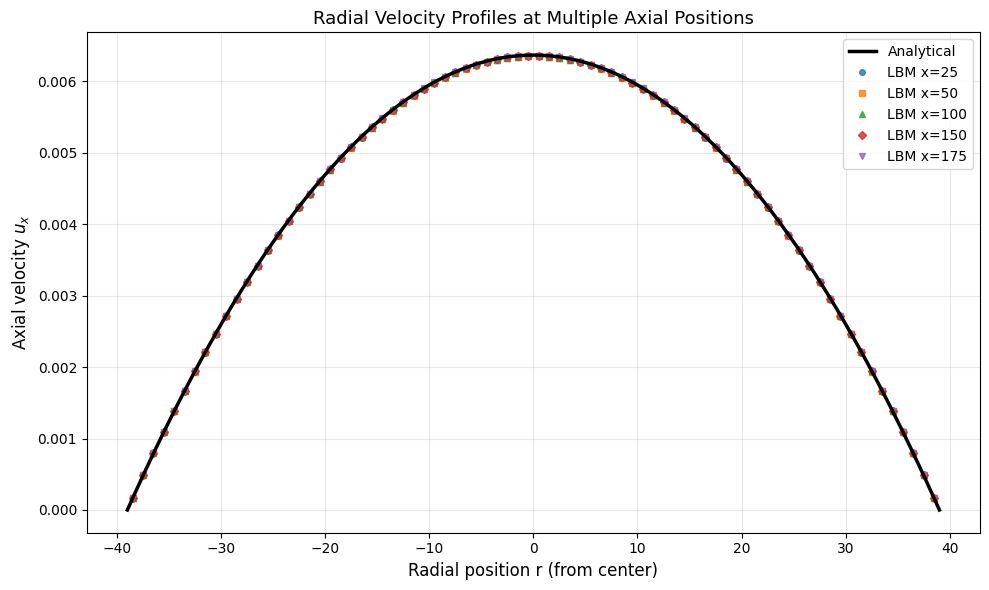

In [24]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
markers = ['o', 's', '^', 'D', 'v']

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(r_analytical, u_analytical, 'k-', linewidth=2.5, label='Analytical', zorder=10)
for idx, xi in enumerate(x_sample_positions):
    ux_slice = ux_np[xi, :, z_mid]
    ux_fl = ux_slice[fluid_mask_radial]
    ax.plot(r_fluid, ux_fl, markers[idx], color=colors[idx], markersize=4,
            label=f'LBM x={xi}', alpha=0.8)
ax.set_xlabel('Radial position r (from center)', fontsize=12)
ax.set_ylabel('Axial velocity $u_x$', fontsize=12)
ax.set_title('Radial Velocity Profiles at Multiple Axial Positions', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 2: Centerline Velocity Along Pipe

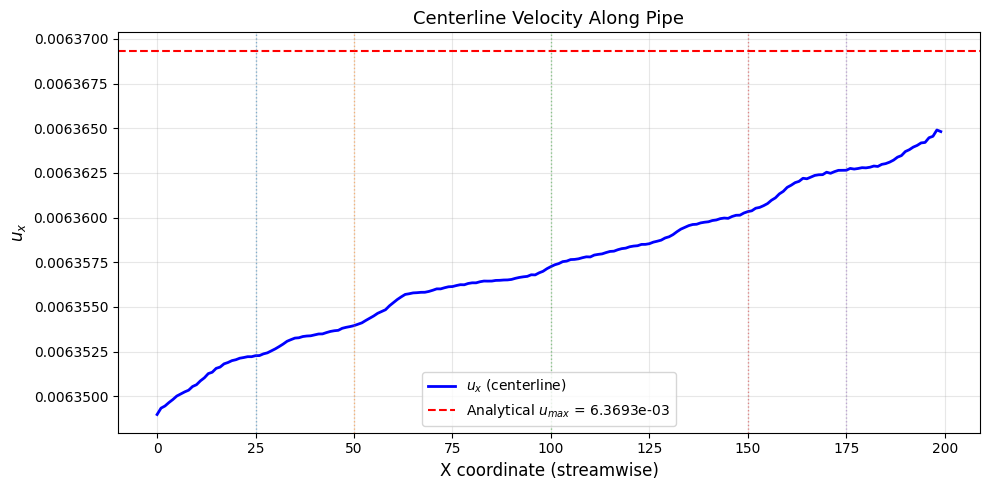

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_coords, ux_centerline, 'b-', linewidth=2, label='$u_x$ (centerline)')
ax.axhline(u_max_analytical, color='r', linestyle='--',
           label=f'Analytical $u_{{max}}$ = {u_max_analytical:.4e}')
for idx, xi in enumerate(x_sample_positions):
    ax.axvline(xi, color=colors[idx], linestyle=':', alpha=0.5, linewidth=1)
ax.set_xlabel('X coordinate (streamwise)', fontsize=12)
ax.set_ylabel('$u_x$', fontsize=12)
ax.set_title('Centerline Velocity Along Pipe', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 3: Centerline Pressure Along Pipe

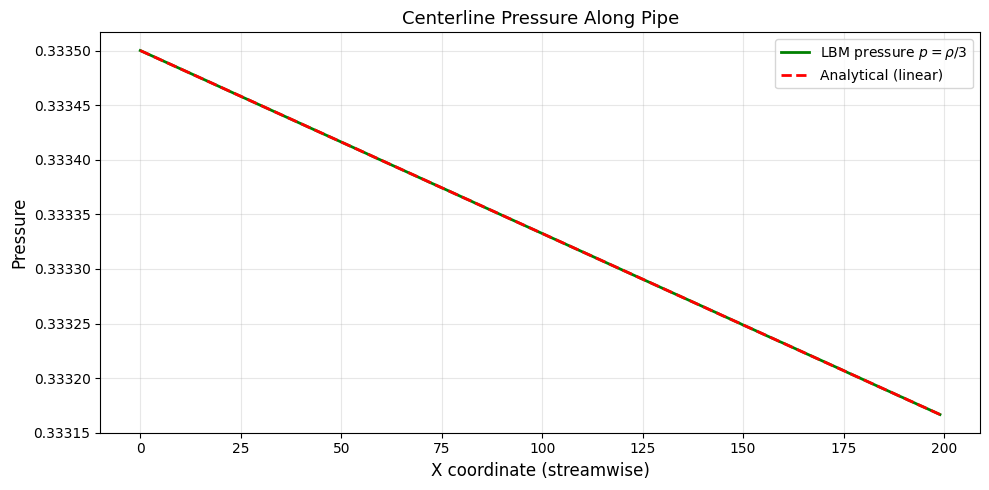

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_coords, p_centerline, 'g-', linewidth=2, label='LBM pressure $p = \\rho/3$')
p_analytical = RHO_IN / 3.0 + dp_dx * x_coords
ax.plot(x_coords, p_analytical, 'r--', linewidth=2, label='Analytical (linear)')
ax.set_xlabel('X coordinate (streamwise)', fontsize=12)
ax.set_ylabel('Pressure', fontsize=12)
ax.set_title('Centerline Pressure Along Pipe', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 4: L2 Relative Error Along the Pipe Length

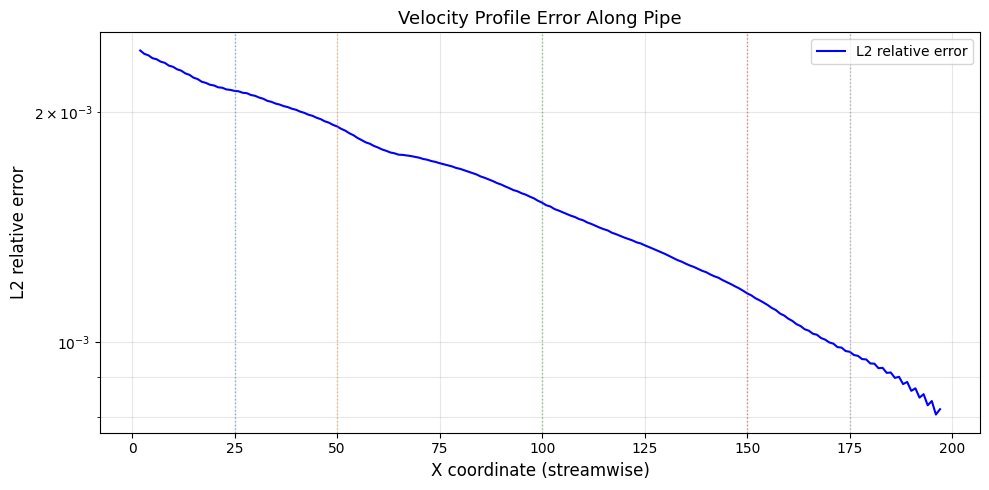

In [27]:
x_err_range = np.arange(2, NX - 2)
l2_errors = np.zeros(len(x_err_range))
for i, xi in enumerate(x_err_range):
    ux_slice = ux_np[xi, :, z_mid]
    ux_fl = ux_slice[fluid_mask_radial]
    l2_errors[i] = np.sqrt(np.mean((ux_fl - u_analytical_at_nodes)**2)) / u_max_analytical

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(x_err_range, l2_errors, 'b-', linewidth=1.5, label='L2 relative error')
for idx, xi in enumerate(x_sample_positions):
    ax.axvline(xi, color=colors[idx], linestyle=':', alpha=0.5, linewidth=1)
ax.set_xlabel('X coordinate (streamwise)', fontsize=12)
ax.set_ylabel('L2 relative error', fontsize=12)
ax.set_title('Velocity Profile Error Along Pipe', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Plot 5: Cross-Section Velocity Contour at Mid-Plane

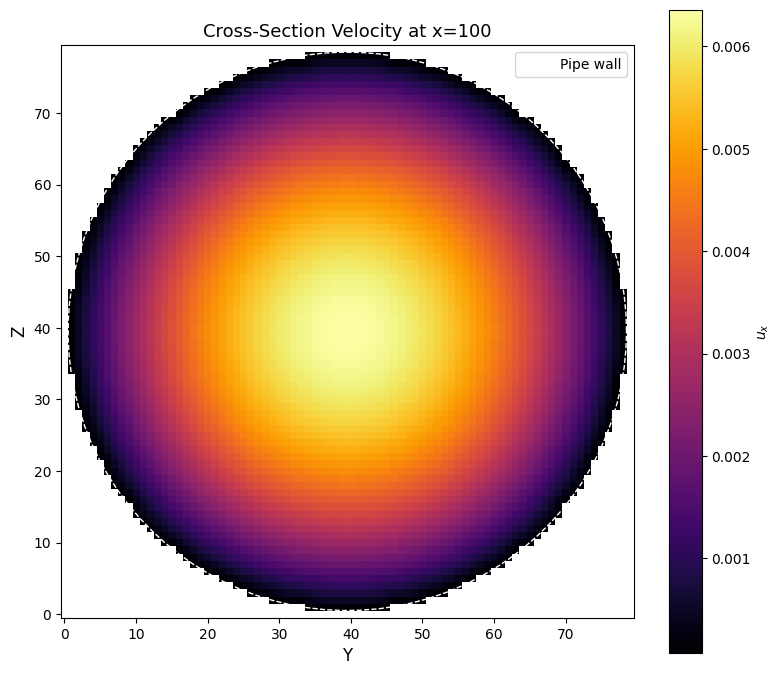

In [28]:
mid_x = NX // 2
ux_mid = ux_np[mid_x]
ux_display = np.where(~wall_2d, ux_mid, np.nan)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(ux_display.T, origin='lower', cmap='inferno', aspect='equal')
plt.colorbar(im, ax=ax, label='$u_x$')
theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(CY_pipe + R_pipe * np.cos(theta) - 0.5, CZ_pipe + R_pipe * np.sin(theta) - 0.5,
        'w--', linewidth=1, label='Pipe wall')
ax.set_xlabel('Y', fontsize=12)
ax.set_ylabel('Z', fontsize=12)
ax.set_title(f'Cross-Section Velocity at x={mid_x}', fontsize=13)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Plot 6: Flow Development Along the Pipe (Velocity Profiles + Pressure Drop)

Re = 2.5,  Estimated entrance length Le = 12 lu  (pipe length = 200)


/tmp/ipykernel_4152601/1786451411.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


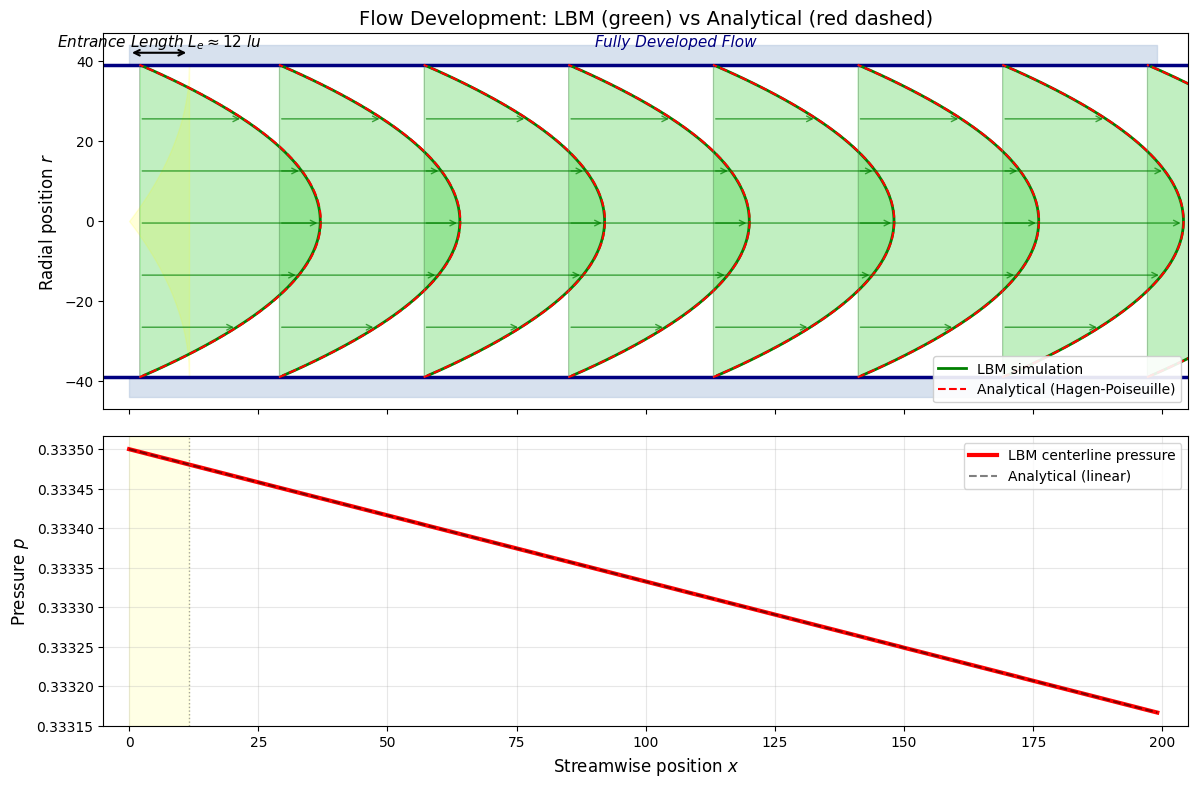

In [31]:
# --- Flow development diagram: LBM vs Analytical velocity profiles + pressure drop ---

# Sample cross-sections to draw velocity profiles
n_profiles = 8
x_profile_positions = np.linspace(2, NX - 3, n_profiles, dtype=int)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                      gridspec_kw={'height_ratios': [1.3, 1], 'hspace': 0.08})

# ============ TOP PANEL: Pipe outline + LBM vs Analytical profiles ============
# Draw pipe walls
ax_top.axhline(R_pipe, color='navy', linewidth=2.5)
ax_top.axhline(-R_pipe, color='navy', linewidth=2.5)
ax_top.fill_between([0, NX - 1], R_pipe, R_pipe + 5, color='lightsteelblue', alpha=0.5)
ax_top.fill_between([0, NX - 1], -R_pipe, -R_pipe - 5, color='lightsteelblue', alpha=0.5)

# Scale factor for drawing velocity profiles inside the pipe
u_max_sim = float(np.max(ux_np[NX // 2, :, NZ // 2]))
profile_scale = R_pipe * 0.9 / u_max_analytical  # Scale by analytical max so both use same scale

# Analytical parabola on fine radial grid (for smooth curve)
r_fine = np.linspace(-R_pipe, R_pipe, 200)
u_analytical_fine = -dp_dx / (4.0 * NU) * (R_pipe**2 - r_fine**2)

# Draw velocity profiles at each cross-section
for i_prof, xi in enumerate(x_profile_positions):
    ux_slice = ux_np[xi, :, z_mid]
    r_all = np.arange(NY) + 0.5 - CY_pipe
    mask = ~wall_2d[:, z_mid]
    r_f = r_all[mask]
    u_f = ux_slice[mask]

    # --- LBM profile (green, filled) ---
    profile_x_lbm = xi + u_f * profile_scale
    ax_top.fill_betweenx(r_f, xi, profile_x_lbm, color='limegreen', alpha=0.3)
    lbm_line, = ax_top.plot(profile_x_lbm, r_f, color='green', linewidth=2)

    # --- Analytical profile (red, dashed) ---
    profile_x_ana = xi + u_analytical_fine * profile_scale
    ana_line, = ax_top.plot(profile_x_ana, r_fine, color='red', linewidth=1.5, linestyle='--')

    # Baseline vertical line at this cross-section
    ax_top.plot([xi, xi], [-R_pipe, R_pipe], color='gray', linewidth=0.6, linestyle='-', alpha=0.4)

    # Draw a few horizontal arrows (LBM)
    n_arrows = 7
    arrow_indices = np.linspace(0, len(r_f) - 1, n_arrows, dtype=int)
    for ai in arrow_indices:
        if u_f[ai] > u_max_sim * 0.05:
            ax_top.annotate('', xy=(xi + u_f[ai] * profile_scale, r_f[ai]),
                          xytext=(xi, r_f[ai]),
                          arrowprops=dict(arrowstyle='->', color='green', lw=1.0, alpha=0.7))

# Legend (use the last drawn lines)
ax_top.legend([lbm_line, ana_line], ['LBM simulation', 'Analytical (Hagen-Poiseuille)'],
             loc='lower right', fontsize=10, framealpha=0.9)

# Entrance length estimate: Le ~ 0.06 * Re * D
u_mean = u_max_sim / 2.0
D_pipe = 2 * R_pipe
Re = u_mean * D_pipe / NU
Le = 0.06 * Re * D_pipe
Le = min(Le, NX * 0.8)

# Shade the developing region
x_env = np.linspace(0, Le, 100)
bl_top = R_pipe * (1 - (1 - x_env / Le) ** 0.5)
bl_bot = -R_pipe * (1 - (1 - x_env / Le) ** 0.5)
ax_top.fill_between(x_env, bl_bot, bl_top, color='yellow', alpha=0.15)

# Annotate entrance length
ax_top.annotate('', xy=(Le, R_pipe + 3), xytext=(0, R_pipe + 3),
              arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax_top.text(Le / 2, R_pipe + 4.5, f'Entrance Length $L_e \\approx {Le:.0f}$ lu',
           ha='center', fontsize=11, fontstyle='italic')

if Le < NX * 0.75:
    mid_fd = (Le + NX) / 2
    ax_top.text(mid_fd, R_pipe + 4.5, 'Fully Developed Flow',
               ha='center', fontsize=11, fontstyle='italic', color='navy')

ax_top.set_ylabel('Radial position $r$', fontsize=12)
ax_top.set_title('Flow Development: LBM (green) vs Analytical (red dashed)', fontsize=14)
ax_top.set_ylim(-R_pipe - 8, R_pipe + 8)
ax_top.set_xlim(-5, NX + 5)
ax_top.set_aspect('auto')

# ============ BOTTOM PANEL: Pressure along the pipe ============
ax_bot.plot(x_coords, p_centerline, 'r-', linewidth=3, label='LBM centerline pressure')
p_analytical_line = RHO_IN / 3.0 + dp_dx * x_coords
ax_bot.plot(x_coords, p_analytical_line, 'k--', linewidth=1.5, alpha=0.5, label='Analytical (linear)')

ax_bot.axvspan(0, Le, color='yellow', alpha=0.1)
ax_bot.axvline(Le, color='gray', linestyle=':', linewidth=1, alpha=0.7)

ax_bot.set_xlabel('Streamwise position $x$', fontsize=12)
ax_bot.set_ylabel('Pressure $p$', fontsize=12)
ax_bot.legend(fontsize=10)
ax_bot.grid(True, alpha=0.3)

print(f"Re = {Re:.1f},  Estimated entrance length Le = {Le:.0f} lu  (pipe length = {NX})")

plt.tight_layout()
plt.show()